### Burgers Equation.

$$ \dfrac{\partial u}{\partial t} + u\dfrac{\partial u}{\partial x} = \nu\dfrac{\partial^2 u}{\partial x^2} $$

We want solve this Burgers-equation for the using a PINN.

Domain :

$$ t\in[0,1] $$
$$ x\in[-1,1] $$

Boundary Conditions :

$$ u(-1,t) = u(1,t) = 0, \forall\space t\in [0,1] $$

Initial Conditions :

$$ u(x,0) = -\sin(\pi x) $$

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [2]:
# parameters
nu = 0.01/torch.pi

In [3]:
# defining the domain
N_x = 51
N_t = 51
x = torch.linspace(-1.0, 1.0, N_x, requires_grad=True)
t = torch.linspace(0.0, 1.0, N_t, requires_grad=True)

x_mesh, t_mesh = torch.meshgrid(x,t)
# print(x_mesh,t_mesh)
input = torch.column_stack((x_mesh.flatten(),t_mesh.flatten()))
print(input.shape)

torch.Size([2601, 2])


C:\Users\ANUNAY CHANDRA\AppData\Roaming\Python\Python310\site-packages\torch\functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4316.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [4]:
# defining the model
model = nn.Sequential(
    nn.Linear(2,20),
    nn.Tanh(),
    nn.Linear(20,20),
    nn.Tanh(),
    nn.Linear(20,1)
)

In [5]:
# loss function
def Loss(model,x,t,x_mesh,t_mesh,input):
    u = model(input).reshape(N_x,N_t)
    
    # gradients
    # time gradients
    dudt = torch.autograd.grad(
        outputs = u,
        inputs = t_mesh,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    # space gradients
    dudx = torch.autograd.grad(
        outputs = u,
        inputs = x_mesh,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    d2udx2 = torch.autograd.grad(
        outputs = dudx,
        inputs = x_mesh,
        grad_outputs=torch.ones_like(dudx),
        create_graph=True
    )[0]

    # ode loss
    loss_ode = torch.mean((dudt + u*dudx - nu * d2udx2)**2)

    # bc loss
    loss_bc = torch.mean(u[0,:]**2 + u[-1,:]**2)

    # ic loss
    loss_ic = torch.mean((u[:,0] + torch.sin(torch.pi * x))**2)

    return loss_ode + loss_ic + loss_bc

In [6]:
# optimizers
adam_optim = torch.optim.Adam(model.parameters(), lr = 0.001)
lbfgs_optim = torch.optim.LBFGS(model.parameters(), lr = 1.0, max_iter=50000, max_eval= 50000, tolerance_grad=10**-9, tolerance_change=10**-12, line_search_fn="strong_wolfe")

In [7]:
# training the PINN using Adam optimizer
N_epoch_adam = 10000
loss_arr_adam = []
print("Training using Adam Optimizer started")
for epoch in range(N_epoch_adam):
    loss = Loss(model, x, t, x_mesh, t_mesh, input)
    loss_arr_adam.append(loss.item())
    loss.backward()
    adam_optim.step()
    adam_optim.zero_grad()
print("Training using Adam Optimizer finished")

Training using Adam Optimizer started
Training using Adam Optimizer finished


In [8]:
# training the PINN using lbfgs optimizer after the Adam optimizer
loss_arr_lbfgs = []

def closure():
    lbfgs_optim.zero_grad()
    loss = Loss(model, x, t, x_mesh, t_mesh, input)
    loss_arr_lbfgs.append(loss.item())
    loss.backward()
    return loss

print("Training using LBFGS Optimizer started")
lbfgs_optim.step(closure)
print("Training using LBFGS Optimizer finished")

Training using LBFGS Optimizer started
Training using LBFGS Optimizer finished


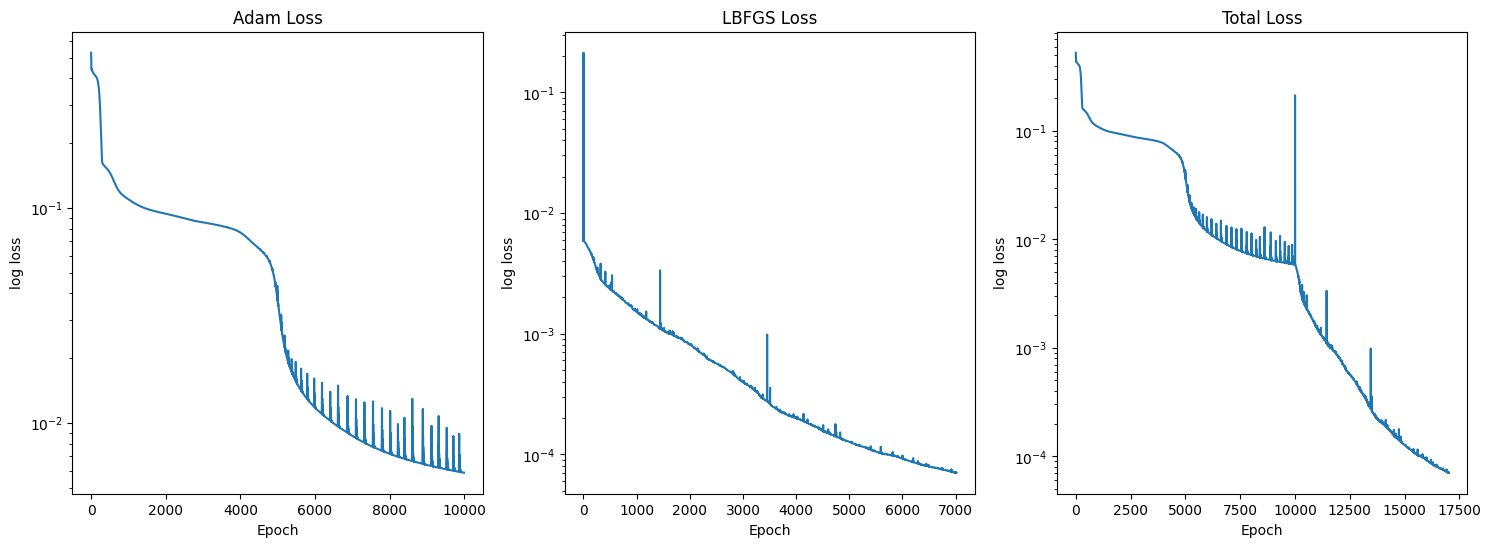

In [9]:
# loss visualisation
plt.figure(figsize = (18,6))

plt.subplot(1,3,1)
plt.semilogy(loss_arr_adam)
plt.title("Adam Loss")
plt.xlabel("Epoch")
plt.ylabel("log loss")

plt.subplot(1,3,2)
plt.semilogy(loss_arr_lbfgs)
plt.title("LBFGS Loss")
plt.xlabel("Epoch")
plt.ylabel("log loss")

plt.subplot(1,3,3)
plt.semilogy(loss_arr_adam + loss_arr_lbfgs)
plt.title("Total Loss")
plt.xlabel("Epoch")
plt.ylabel("log loss")
plt.show()

In [10]:
# PINN predicted function
with torch.no_grad():
    u_nn = model(input).reshape(N_x,N_t)

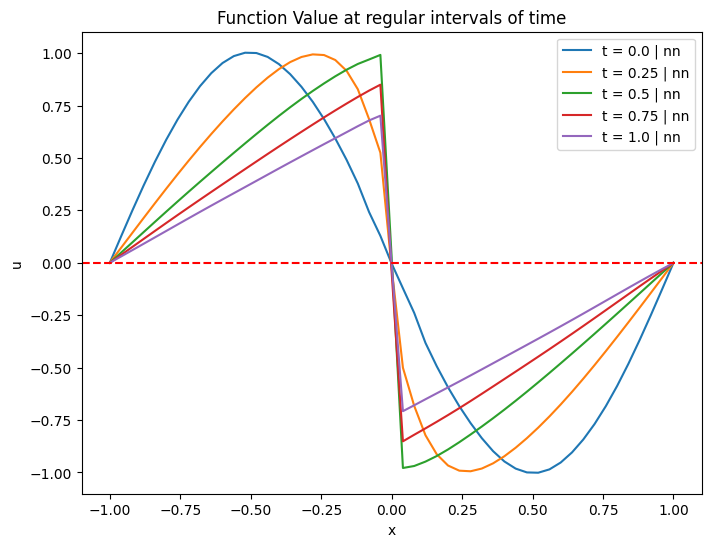

In [11]:
# visualising u(x,t) at fixed intervals of time
times = [0.0, 0.25, 0.5, 0.75, 1.0]
plt.figure(figsize = (8,6))

for time in times:
    index = int(time/(1.0/(N_t-1)))
    # print(time,index)
    plt.plot(x.detach().flatten(),u_nn[:,index].detach().flatten(),label = f't = {time} | nn')
plt.axhline(0,c='red',ls = '--')
plt.legend()
plt.title("Function Value at regular intervals of time")
plt.xlabel("x")
plt.ylabel("u")
plt.show()

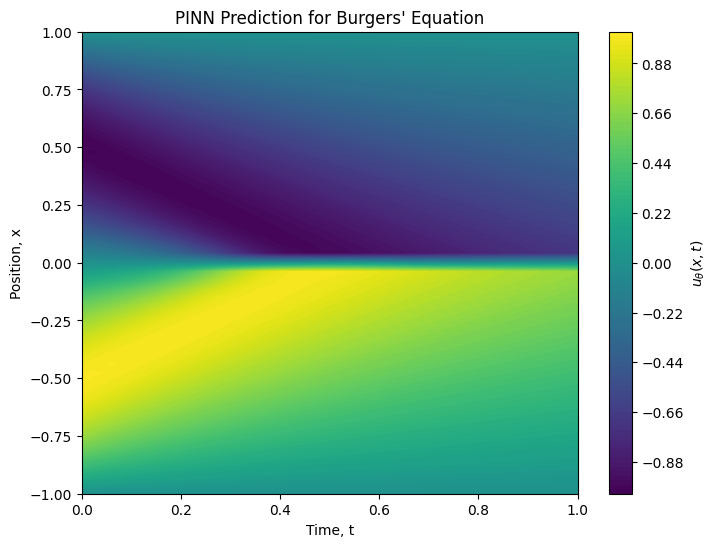

In [12]:
# visualising the PINN-predicted solution
plt.figure(figsize=(8, 6))

contour = plt.contourf(
    t_mesh.detach(),
    x_mesh.detach(),
    u_nn.detach(),
    levels=100,
    cmap="viridis"
)

plt.title("PINN Prediction for Burgers' Equation")
plt.xlabel("Time, t")
plt.ylabel("Position, x")

plt.colorbar(
    contour,
    label=r"$u_\theta(x,t)$"
)

plt.show()